#### Actividad 6.2

Ivanna Maldonado Cervantes


In [1]:
#Importamos las librerias pandas, numpy y matplotlib respectivamente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
pd.set_option("display.max_rows", None)

In [3]:
#Carga desde un archivo .csv sin indice
data= pd.read_csv('listingscambridge.csv') 
data = data.drop('calendar_updated', axis=1)
data = data.drop('neighbourhood_group_cleansed', axis=1)
data["price"] = data["price"].replace('[\$,]', '', regex=True)
data["price"] = data["price"].astype(float)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1358 entries, 0 to 1357
Data columns (total 77 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            1358 non-null   int64  
 1   listing_url                                   1358 non-null   object 
 2   scrape_id                                     1358 non-null   int64  
 3   last_scraped                                  1358 non-null   object 
 4   source                                        1358 non-null   object 
 5   name                                          1358 non-null   object 
 6   description                                   1347 non-null   object 
 7   neighborhood_overview                         694 non-null    object 
 8   picture_url                                   1358 non-null   object 
 9   host_id                                       1358 non-null   i

<>:5: SyntaxWarning: invalid escape sequence '\$'
<>:5: SyntaxWarning: invalid escape sequence '\$'
/var/folders/vv/zkrntk9d6sjc4rn30m21zp2w0000gp/T/ipykernel_31952/2498267207.py:5: SyntaxWarning: invalid escape sequence '\$'
  data["price"] = data["price"].replace('[\$,]', '', regex=True)


In [4]:
#Corroboramos valores nulos
valores_nulos=data.isnull().sum()
valores_nulos

id                                                0
listing_url                                       0
scrape_id                                         0
last_scraped                                      0
source                                            0
name                                              0
description                                      11
neighborhood_overview                           664
picture_url                                       0
host_id                                           0
host_url                                          0
host_name                                         0
host_since                                        0
host_location                                   250
host_about                                      480
host_response_time                              111
host_response_rate                              111
host_acceptance_rate                             86
host_is_superhost                                41
host_thumbna

In [5]:
data.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'latitude', 'longitude', 'property_type',
       'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms',
       'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights',
       'minimum_minimum_nights', 'maximum_minimum_nights',
       'minimum_maximum_nights', 'maximum_maximum_nights',
       'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'has_availability',
       'availability_3

In [6]:
#Aplicar métodos (Desviación Estándar y Rango Intercuartílico) para eliminar Outliers, 
# comprobar con diagramas de caja por cada columna

In [7]:
#Reemplazamos valores nulos del dataframe con "bfill"
data1 =data.fillna(method="ffill") 
data1.head()

/var/folders/vv/zkrntk9d6sjc4rn30m21zp2w0000gp/T/ipykernel_31952/1210798527.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data1 =data.fillna(method="ffill")


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,8521,https://www.airbnb.com/rooms/8521,20250928035003,2025-09-28,city scrape,SunsplashedSerenity walk to Harvard & Fresh Pond,"An elegant, sun-splashed, 2 bedroom (+2offices...",Huron Village is known for its charm. We have...,https://a0.muscache.com/pictures/30536/072e0a5...,306681,...,4.92,4.94,4.74,C0121120491,f,2,2,0,0,0.41
1,11169,https://www.airbnb.com/rooms/11169,20250928035003,2025-09-28,city scrape,Lovely Studio Room: Available for long w/ends,Large sunny room w kitchenette & bath. Foam ma...,The neighborhood is quiet and friendly and our...,https://a0.muscache.com/pictures/miso/Hosting-...,40965,...,4.92,4.80,4.77,C0121120491,f,3,1,2,0,1.01
2,19581,https://www.airbnb.com/rooms/19581,20250928035003,2025-09-28,city scrape,"Furnished suite, Windsor","Welcome to Area IV! We are located, convenient...",The neighborhood is quiet and friendly and our...,https://a0.muscache.com/pictures/188f1b4b-f37b...,74249,...,4.91,4.91,4.27,C0121120491,t,3,0,3,0,0.07
3,27498,https://www.airbnb.com/rooms/27498,20250928035003,2025-09-28,city scrape,Furnished suite 2 @ the Windsor,"Welcome to Area IV! We are located, convenient...",The neighborhood is quiet and friendly and our...,https://a0.muscache.com/pictures/bab30c3c-ff3c...,74249,...,4.76,4.88,4.64,C0121120491,t,3,0,3,0,0.15
4,79762,https://www.airbnb.com/rooms/79762,20250928035003,2025-09-28,city scrape,Cambridge Getaway @ Harvard & MIT,Charming 2-bedroom apartment on the third floo...,Annmarie and I have lived in this area for ove...,https://a0.muscache.com/pictures/airflow/Hosti...,430015,...,4.93,4.93,4.77,STR-15661,f,1,1,0,0,2.59


In [8]:
#Creo 2 dataframe para poder procesar los outliers
cualitativos = [
    'id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
    'description', 'neighborhood_overview', 'picture_url', 'host_id',
    'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
    'host_response_time', 'host_response_rate', 'host_acceptance_rate',
    'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
    'host_neighbourhood', 'host_verifications', 'host_has_profile_pic',
    'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed',
    'property_type', 'room_type', 'bathrooms_text', 'amenities', 'has_availability',
    'calendar_last_scraped', 'first_review', 'last_review', 'license',
    'instant_bookable'
]
cuantitativos= [
    'latitude', 'longitude', 'host_listings_count', 'host_total_listings_count',
    'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price',
    'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
    'maximum_minimum_nights', 'minimum_maximum_nights',
    'maximum_maximum_nights', 'minimum_nights_avg_ntm',
    'maximum_nights_avg_ntm', 'availability_30', 'availability_60',
    'availability_90', 'availability_365', 'number_of_reviews',
    'number_of_reviews_ltm', 'number_of_reviews_l30d', 'availability_eoy',
    'number_of_reviews_ly', 'estimated_occupancy_l365d',
    'estimated_revenue_l365d', 'review_scores_rating',
    'review_scores_accuracy', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication',
    'review_scores_location', 'review_scores_value',
    'calculated_host_listings_count',
    'calculated_host_listings_count_entire_homes',
    'calculated_host_listings_count_private_rooms',
    'calculated_host_listings_count_shared_rooms',
    'reviews_per_month'
]

df_cuali = data1[cualitativos]
df_cuanti = data1[cuantitativos]

<Figure size 1500x800 with 0 Axes>

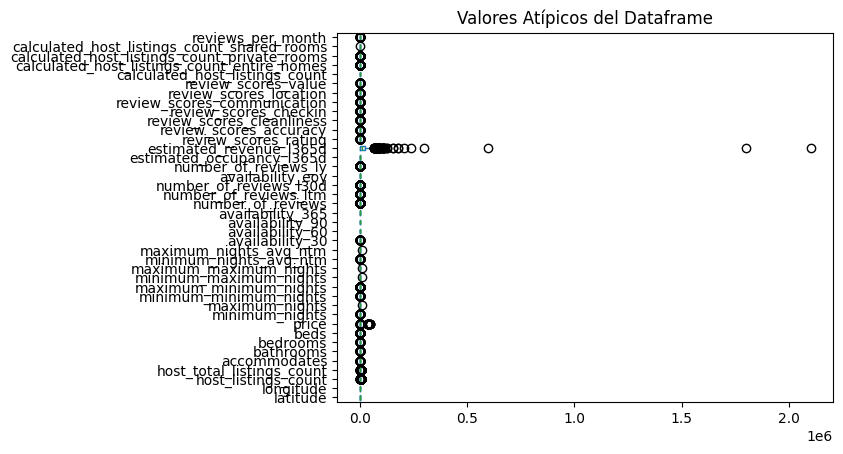

In [9]:
#Realizamos diagrama de caja o bigote de cada columna del dataframe
fig = plt.figure(figsize =(15, 8))
df_cuanti.plot(kind='box', vert=False)
plt.title("Valores Atípicos del Dataframe")
plt.show() #dibujamos el diagrama

In [10]:
#Método aplicando desviación estandar. Encuentro los valores extremos
#desv est detecta menos datos outliers que interquartilicos.
y=df_cuanti
Limite_Superior= y.mean() + 3*y.std()
Limite_Inferior= y.mean() - 3*y.std()
print("Limite superior permitido", Limite_Superior)
print("Limite inferior permitido", Limite_Inferior)

Limite superior permitido latitude                                            42.405787
longitude                                          -71.049404
host_listings_count                               5743.182563
host_total_listings_count                         6670.380342
accommodates                                        10.217804
bathrooms                                            3.021984
bedrooms                                             4.534661
beds                                                 6.200888
price                                            18420.864297
minimum_nights                                     123.733495
maximum_nights                                    2091.401907
minimum_minimum_nights                             121.287413
maximum_minimum_nights                             358.339617
minimum_maximum_nights                            2198.349852
maximum_maximum_nights                            2208.944064
minimum_nights_avg_ntm                      

In [11]:
#Obtenemos datos y los outliers se convierten en nulos en el DataFrame
data2= df_cuanti[(y<=Limite_Superior)&(y>=Limite_Inferior)]
data2.head()

,latitude,longitude,host_listings_count,host_total_listings_count,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,42.38258,-71.13646,2,3,5.0,1.0,2.0,2.0,270.0,2.0,...,4.97,4.90,4.92,4.94,4.74,2,2,0,0.0,0.41
1,42.39630,-71.13135,4,4,3.0,1.0,1.0,0.0,126.0,3.0,...,4.78,4.91,4.92,4.80,4.77,3,1,2,0.0,1.01
2,42.36258,-71.09603,3,3,1.0,1.0,1.0,1.0,183.0,10.0,...,4.64,4.64,4.91,4.91,4.27,3,0,3,0.0,0.07
3,42.36254,-71.09698,3,3,2.0,1.0,1.0,1.0,238.0,5.0,...,4.76,4.64,4.76,4.88,4.64,3,0,3,0.0,0.15
4,42.36950,-71.09921,1,2,4.0,1.0,2.0,2.0,300.0,3.0,...,4.87,4.96,4.93,4.93,4.77,1,1,0,0.0,2.59


In [12]:
#Corroboramos valores nulos del dataframe 4
valores_nulos=data2.isnull().sum()
valores_nulos

latitude                                         0
longitude                                        0
host_listings_count                              0
host_total_listings_count                        0
accommodates                                    20
bathrooms                                       12
bedrooms                                        17
beds                                            23
price                                           27
minimum_nights                                   8
maximum_nights                                   1
minimum_minimum_nights                           9
maximum_minimum_nights                           2
minimum_maximum_nights                           1
maximum_maximum_nights                           1
minimum_nights_avg_ntm                           9
maximum_nights_avg_ntm                           1
availability_30                                  0
availability_60                                  0
availability_90                

In [13]:
#Reemplazamos valores atípicos (nulos) del dataframe con "mean"
#Realizamos una copia del dataframe
data_clean=data2.copy()
data_clean=data_clean.fillna(round(data2.mean(),1))
data_clean.head()

,latitude,longitude,host_listings_count,host_total_listings_count,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,42.38258,-71.13646,2,3,5.0,1.0,2.0,2.0,270.0,2.0,...,4.97,4.90,4.92,4.94,4.74,2,2,0,0.0,0.41
1,42.39630,-71.13135,4,4,3.0,1.0,1.0,0.0,126.0,3.0,...,4.78,4.91,4.92,4.80,4.77,3,1,2,0.0,1.01
2,42.36258,-71.09603,3,3,1.0,1.0,1.0,1.0,183.0,10.0,...,4.64,4.64,4.91,4.91,4.27,3,0,3,0.0,0.07
3,42.36254,-71.09698,3,3,2.0,1.0,1.0,1.0,238.0,5.0,...,4.76,4.64,4.76,4.88,4.64,3,0,3,0.0,0.15
4,42.36950,-71.09921,1,2,4.0,1.0,2.0,2.0,300.0,3.0,...,4.87,4.96,4.93,4.93,4.77,1,1,0,0.0,2.59


In [14]:
#Corroboramos valores nulos del dataframe LIMPIO
valores_nulos=data_clean.isnull().sum()
valores_nulos

latitude                                        0
longitude                                       0
host_listings_count                             0
host_total_listings_count                       0
accommodates                                    0
bathrooms                                       0
bedrooms                                        0
beds                                            0
price                                           0
minimum_nights                                  0
maximum_nights                                  0
minimum_minimum_nights                          0
maximum_minimum_nights                          0
minimum_maximum_nights                          0
maximum_maximum_nights                          0
minimum_nights_avg_ntm                          0
maximum_nights_avg_ntm                          0
availability_30                                 0
availability_60                                 0
availability_90                                 0


In [15]:
#Método aplicando Cuartiles. Encuentro cuartiles 0.25 y 0.75
y=df_cuanti

percentile25=y.quantile(0.25) #Q1
percentile75=y.quantile(0.75) #Q3
iqr= percentile75 - percentile25

Limite_Superior_iqr= percentile75 + 1.5*iqr
Limite_Inferior_iqr= percentile25 - 1.5*iqr
print("Limite superior permitido", Limite_Superior_iqr)
print("Limite inferior permitido", Limite_Inferior_iqr)

Limite superior permitido latitude                                           42.403910
longitude                                         -71.048916
host_listings_count                               418.000000
host_total_listings_count                         579.000000
accommodates                                        7.000000
bathrooms                                           2.250000
bedrooms                                            3.500000
beds                                                3.500000
price                                             629.250000
minimum_nights                                     72.000000
maximum_nights                                   2265.000000
minimum_minimum_nights                             73.500000
maximum_minimum_nights                             70.500000
minimum_maximum_nights                           2265.000000
maximum_maximum_nights                           2265.000000
minimum_nights_avg_ntm                             72.00000

In [16]:
#Obtenemos datos limpios del Dataframe
data2_iqr= df_cuanti[(y<=Limite_Superior_iqr)&(y>=Limite_Inferior_iqr)]
data2_iqr.head()

,latitude,longitude,host_listings_count,host_total_listings_count,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,42.38258,-71.13646,2.0,3.0,5.0,1.0,2.0,2.0,270.0,2.0,...,4.97,4.90,4.92,4.94,4.74,2,2.0,0.0,0.0,0.41
1,42.39630,-71.13135,4.0,4.0,3.0,1.0,1.0,0.0,126.0,3.0,...,4.78,4.91,4.92,4.80,4.77,3,1.0,2.0,0.0,1.01
2,42.36258,-71.09603,3.0,3.0,1.0,1.0,1.0,1.0,183.0,10.0,...,4.64,NaN,4.91,4.91,4.27,3,0.0,3.0,0.0,0.07
3,42.36254,-71.09698,3.0,3.0,2.0,1.0,1.0,1.0,238.0,5.0,...,4.76,NaN,4.76,4.88,4.64,3,0.0,3.0,0.0,0.15
4,42.36950,-71.09921,1.0,2.0,4.0,1.0,2.0,2.0,300.0,3.0,...,4.87,4.96,4.93,4.93,4.77,1,1.0,0.0,0.0,2.59


In [17]:
#Corroboramos valores nulos del dataframe LIMPIO
valores_nulos=data2_iqr.isnull().sum()
valores_nulos

latitude                                          0
longitude                                         0
host_listings_count                             192
host_total_listings_count                       212
accommodates                                     83
bathrooms                                        92
bedrooms                                         75
beds                                            144
price                                            76
minimum_nights                                   95
maximum_nights                                    1
minimum_minimum_nights                           89
maximum_minimum_nights                          241
minimum_maximum_nights                            1
maximum_maximum_nights                            1
minimum_nights_avg_ntm                           96
maximum_nights_avg_ntm                            1
availability_30                                  62
availability_60                                   0
availability

In [18]:
#Reemplazamos valores atípicos (nulos) del dataframe con "mean"
#Realizamos una copia del dataframe
data3_iqr=data2_iqr.copy()
data3_iqr=data3_iqr.fillna(round(data2_iqr.median(),1))
data3_iqr.head()

,latitude,longitude,host_listings_count,host_total_listings_count,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,42.38258,-71.13646,2.0,3.0,5.0,1.0,2.0,2.0,270.0,2.0,...,4.97,4.90,4.92,4.94,4.74,2,2.0,0.0,0.0,0.41
1,42.39630,-71.13135,4.0,4.0,3.0,1.0,1.0,0.0,126.0,3.0,...,4.78,4.91,4.92,4.80,4.77,3,1.0,2.0,0.0,1.01
2,42.36258,-71.09603,3.0,3.0,1.0,1.0,1.0,1.0,183.0,10.0,...,4.64,5.00,4.91,4.91,4.27,3,0.0,3.0,0.0,0.07
3,42.36254,-71.09698,3.0,3.0,2.0,1.0,1.0,1.0,238.0,5.0,...,4.76,5.00,4.76,4.88,4.64,3,0.0,3.0,0.0,0.15
4,42.36950,-71.09921,1.0,2.0,4.0,1.0,2.0,2.0,300.0,3.0,...,4.87,4.96,4.93,4.93,4.77,1,1.0,0.0,0.0,2.59


In [19]:
# Unimos el dataframe cuantitativo limpio con el dataframe cualitativo

Datos_limpios = pd.concat([df_cuali, data3_iqr], axis=1)
Datos_limpios.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,8521,https://www.airbnb.com/rooms/8521,20250928035003,2025-09-28,city scrape,SunsplashedSerenity walk to Harvard & Fresh Pond,"An elegant, sun-splashed, 2 bedroom (+2offices...",Huron Village is known for its charm. We have...,https://a0.muscache.com/pictures/30536/072e0a5...,306681,...,4.97,4.90,4.92,4.94,4.74,2,2.0,0.0,0.0,0.41
1,11169,https://www.airbnb.com/rooms/11169,20250928035003,2025-09-28,city scrape,Lovely Studio Room: Available for long w/ends,Large sunny room w kitchenette & bath. Foam ma...,The neighborhood is quiet and friendly and our...,https://a0.muscache.com/pictures/miso/Hosting-...,40965,...,4.78,4.91,4.92,4.80,4.77,3,1.0,2.0,0.0,1.01
2,19581,https://www.airbnb.com/rooms/19581,20250928035003,2025-09-28,city scrape,"Furnished suite, Windsor","Welcome to Area IV! We are located, convenient...",The neighborhood is quiet and friendly and our...,https://a0.muscache.com/pictures/188f1b4b-f37b...,74249,...,4.64,5.00,4.91,4.91,4.27,3,0.0,3.0,0.0,0.07
3,27498,https://www.airbnb.com/rooms/27498,20250928035003,2025-09-28,city scrape,Furnished suite 2 @ the Windsor,"Welcome to Area IV! We are located, convenient...",The neighborhood is quiet and friendly and our...,https://a0.muscache.com/pictures/bab30c3c-ff3c...,74249,...,4.76,5.00,4.76,4.88,4.64,3,0.0,3.0,0.0,0.15
4,79762,https://www.airbnb.com/rooms/79762,20250928035003,2025-09-28,city scrape,Cambridge Getaway @ Harvard & MIT,Charming 2-bedroom apartment on the third floo...,Annmarie and I have lived in this area for ove...,https://a0.muscache.com/pictures/airflow/Hosti...,430015,...,4.87,4.96,4.93,4.93,4.77,1,1.0,0.0,0.0,2.59


In [20]:
#Corroboramos valores nulos del dataframe LIMPIO
valores_nulos=Datos_limpios.isnull().sum()
valores_nulos

id                                              0
listing_url                                     0
scrape_id                                       0
last_scraped                                    0
source                                          0
name                                            0
description                                     0
neighborhood_overview                           0
picture_url                                     0
host_id                                         0
host_url                                        0
host_name                                       0
host_since                                      0
host_location                                   0
host_about                                      0
host_response_time                              0
host_response_rate                              0
host_acceptance_rate                            0
host_is_superhost                               0
host_thumbnail_url                              0


In [21]:
#Convertir DataFrame a CSV
Datos_limpios.to_csv("Cambridge_Limpios.csv")